Partition 0: 8 rows
Partition 1: 8 rows
Partition 2: 7 rows
Partition 3: 8 rows
Partition 0: ['date,region,sales', '2024-01-01,North,100', '2024-01-01,South,150', '2024-01-02,North,200', '2024-01-02,West,300', '2024-01-03,South,120', '2024-01-03,East,180', '2024-01-04,North,100', '2024-01-04,South,150']
Partition 1: ['2024-01-04,North,200', '2024-01-05,West,300', '2024-01-05,South,120', '2024-01-05,East,180', '2024-01-06,East,180', '2024-01-06,North,100', '2024-01-06,South,150', '2024-01-07,North,200']
Partition 2: ['2024-01-07,West,300', '2024-01-07,South,120', '2024-01-08,North,100', '2024-01-08,South,150', '2024-01-08,West,300', '2024-01-08,East,180', '2024-01-08,North,100']
Partition 3: ['2024-01-09,South,150', '2024-01-09,North,200', '2024-01-09,West,300', '2024-01-09,East,180', '2024-01-10,East,180', '2024-01-10,North,100', '2024-01-10,South,150', '2024-01-10,West,300']


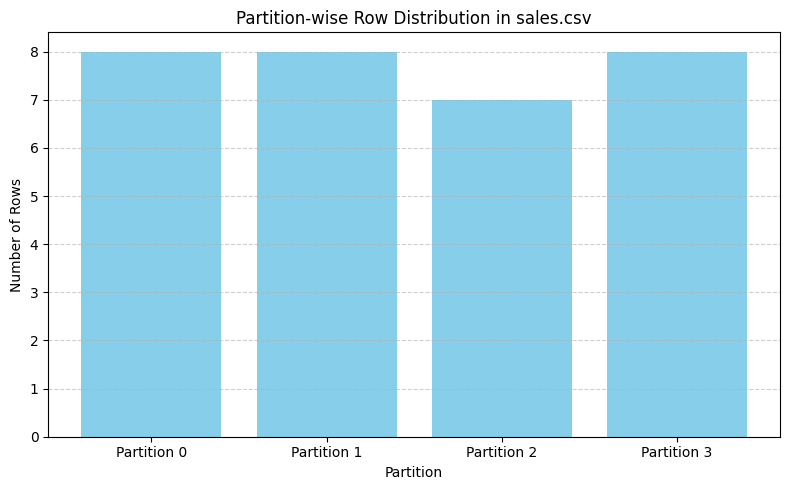

In [9]:
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt

# Start Spark
spark = SparkSession.builder.master("local[*]").appName("SalesPartitionViz").getOrCreate()
sc = spark.sparkContext

# Load the file with 4 partitions
rdd = sc.textFile('/content/drive/My Drive/Colab Notebooks/sales.txt', minPartitions=4)

# Remove header
header = rdd.first()
data_rdd = rdd.filter(lambda row: row != header)

# Count elements per partition
def count_per_partition(index, iterator):
    yield (index, len(list(iterator)))

partition_counts = data_rdd.mapPartitionsWithIndex(count_per_partition).collect()
partition_counts.sort()


# Print partition index and row count
for partition_index, row_count in partition_counts:
    print(f"Partition {partition_index}: {row_count} rows")

# Print partition wise data
def inspect(index, iterator):
    yield f"Partition {index}: {list(iterator)}"

for part in rdd.mapPartitionsWithIndex(inspect).collect():
    print(part)


# Prepare for visualization
partition_labels = [f"Partition {i}" for i, _ in partition_counts]
counts = [count for _, count in partition_counts]


# Bar chart
plt.figure(figsize=(8, 5))
plt.bar(partition_labels, counts, color='skyblue')
plt.title("Partition-wise Row Distribution in sales.csv")
plt.xlabel("Partition")
plt.ylabel("Number of Rows")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
